# **E-commerce Sales & Customer Insights (EDA)**

**1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**2. Load Dataset**

In [ ]:
# Load the built-in 'tips' dataset from Seaborn library
df = sns.load_dataset('tips')

print("--- Initial Data ---")
print(df.head())

# Task: Checking for Missing Values
print("\nMissing Values:\n", df.isnull().sum())

--- Initial Data ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Missing Values:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


**3: Data Cleaning aur Outliers**

Interquartile Range (IQR): 10.779999999999998
Typical bill range (Q1 to Q3): 13.3475 to 24.127499999999998


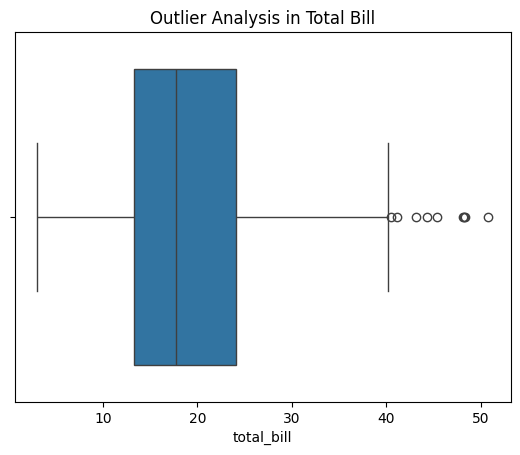

In [ ]:
# Calculate the Interquartile Range (IQR) for 'total_bill' to identify outliers
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

print(f"Interquartile Range (IQR): {IQR}")
print(f"Typical bill range (Q1 to Q3): {Q1} to {Q3}")

# Visualize outliers using a Boxplot
sns.boxplot(x=df['total_bill'])
plt.title('Outlier Analysis in Total Bill')
plt.show()

**4: Data Preprocessing (Encoding & Engineering)**

In [ ]:
# Convert categorical text data into numerical codes for Machine Learning
# 0 = Female, 1 = Male
df['sex_code'] = df['sex'].map({'Female': 0, 'Male': 1})
# 0 = Non-Smoker, 1 = Smoker
df['smoker_code'] = df['smoker'].map({'No': 0, 'Yes': 1})

# Feature Engineering: Calculate tip percentage relative to the total bill
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

# Display the newly created features
print("--- Feature Engineering Results ---")
print(df[['total_bill', 'tip', 'sex_code', 'tip_percentage']].head())

--- Feature Engineering Results ---
   total_bill   tip sex_code  tip_percentage
0       16.99  1.01        0        5.944673
1       10.34  1.66        1       16.054159
2       21.01  3.50        1       16.658734
3       23.68  3.31        1       13.978041
4       24.59  3.61        0       14.680765


**5: Exploratory Data Visualization**

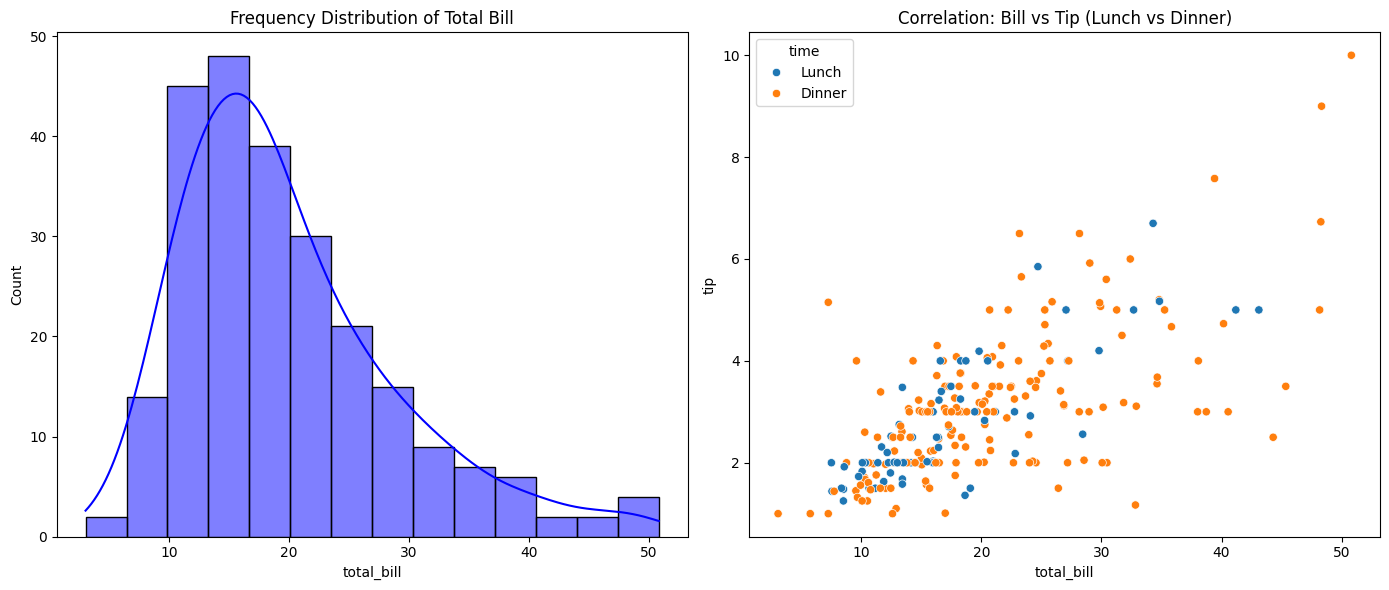

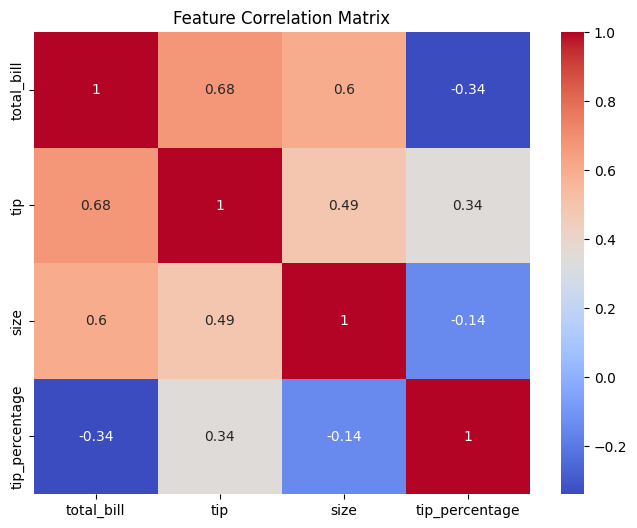

In [ ]:
# Set the figure size for better visibility
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of the total bill amount
plt.subplot(1, 2, 1)
sns.histplot(df['total_bill'], kde=True, color='blue')
plt.title('Frequency Distribution of Total Bill')

# Subplot 2: Relationship between Bill and Tip, categorized by time of day
plt.subplot(1, 2, 2)
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)
plt.title('Correlation: Bill vs Tip (Lunch vs Dinner)')

plt.tight_layout()
plt.show()

# Heatmap to check the correlation between all numerical columns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

**6: Summary and Business Insights**

In [ ]:
# Print final insights for stakeholders or project managers
print("--- Final Project Summary ---")
print(f"Dataset Size: {len(df)} records")
print(f"Average Tip Amount: ${df['tip'].mean():.2f}")
print(f"Maximum Single Bill: ${df['total_bill'].max()}")
print(f"Peak Business Time: {df['time'].mode()[0]}")

--- Final Project Summary ---
Dataset Size: 244 records
Average Tip Amount: $3.00
Maximum Single Bill: $50.81
Peak Business Time: Dinner
